Installation

In [5]:
# Install stable versions
!pip install -q transformers==4.40.0 sentence-transformers==2.6.1 accelerate==0.30.1 \
spacy scikit-learn newsapi-python matplotlib seaborn wordcloud

# Download SpaCy model
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 25.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
!pip install -q rouge-score

Import Libraries


In [2]:
import torch
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from newsapi import NewsApiClient
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from rouge_score import rouge_scorer
from sklearn.metrics.pairwise import cosine_similarity

Load Models


In [3]:
device = 0 if torch.cuda.is_available() else -1

nlp = spacy.load("en_core_web_sm")

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=device
)

sentiment = pipeline("sentiment-analysis", device=device)

embedder = SentenceTransformer('all-MiniLM-L6-v2')

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

print("✅ Models loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Models loaded


NEWS API


In [4]:
API_KEY = "c4521fd871c246fab0c01b15cd3d6711"

newsapi = NewsApiClient(api_key=API_KEY)

all_articles = []
query = "technology OR politics"

# Fetch multiple pages
for page in range(1, 6):
    res = newsapi.get_everything(
        q=query,
        language="en",
        page_size=20,
        page=page
    )
    all_articles.extend(res['articles'])

# Clean data
texts = []
sources = []

for a in all_articles:
    if a['content'] and len(a['content']) > 100:
        texts.append(a['content'])
        sources.append(a['source']['name'])

print(f"✅ Total articles fetched: {len(texts)}")

✅ Total articles fetched: 83


DATA FRAME


In [5]:
df = pd.DataFrame({
    "source": sources,
    "article": texts
})

df = df[:30]

SUMMARIZATION

In [6]:
summaries = []

for t in df["article"]:
    try:
        s = summarizer(t[:1024], max_length=40, min_length=20)[0]['summary_text']
    except:
        s = ""
    summaries.append(s)

df["summary"] = summaries

BIAS DETECTION

In [7]:
df["bias"] = df["article"].apply(lambda x: sentiment(x[:512])[0]["label"])
df["summary_bias"] = df["summary"].apply(lambda x: sentiment(x[:512])[0]["label"])

ROUGE SCORE


In [8]:
scores = []

for i in range(len(df)):
    score = scorer.score(df["article"].iloc[i], df["summary"].iloc[i])
    scores.append(score["rouge1"].fmeasure)

df["rouge1"] = scores

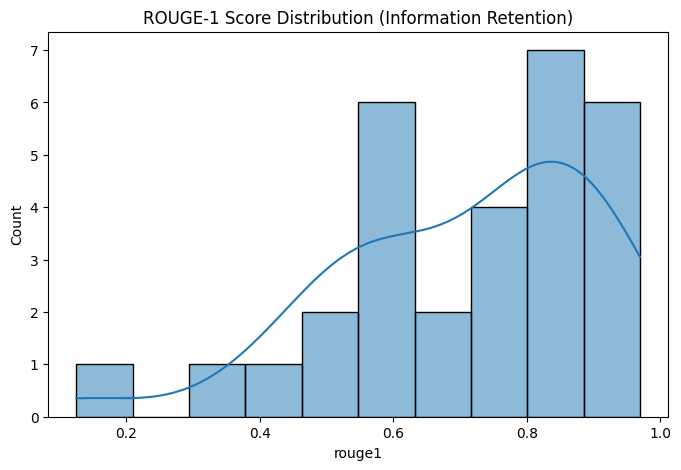

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["rouge1"], bins=10, kde=True)
plt.title("ROUGE-1 Score Distribution (Information Retention)")
plt.show()

Compression Ratio


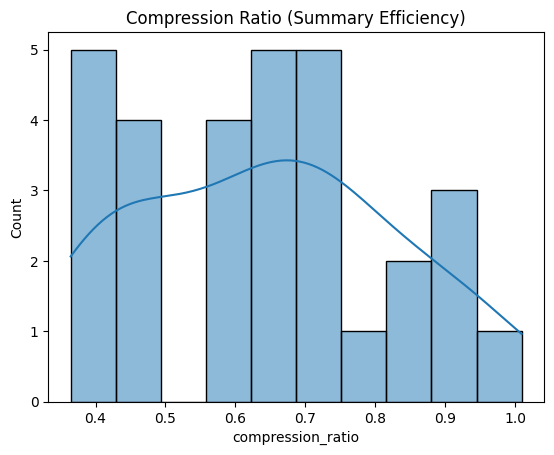

In [10]:
df["compression_ratio"] = df["summary"].str.len() / df["article"].str.len()

sns.histplot(df["compression_ratio"], bins=10, kde=True)
plt.title("Compression Ratio (Summary Efficiency)")
plt.show()

SENTIMENT SHIFT

In [11]:
def label_to_score(label):
    if label == "POSITIVE":
        return 1
    elif label == "NEGATIVE":
        return -1
    return 0

df["bias_score"] = df["bias"].apply(label_to_score)
df["summary_bias_score"] = df["summary_bias"].apply(label_to_score)

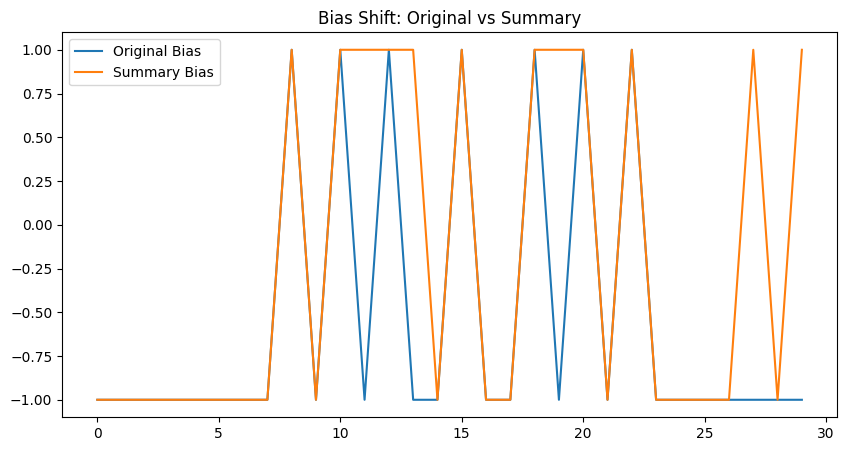

In [12]:
plt.figure(figsize=(10,5))

plt.plot(df["bias_score"].values, label="Original Bias")
plt.plot(df["summary_bias_score"].values, label="Summary Bias")

plt.title("Bias Shift: Original vs Summary")
plt.legend()
plt.show()

COSINE SIMILARITY

In [13]:
orig_emb = embedder.encode(df["article"].tolist())
summ_emb = embedder.encode(df["summary"].tolist())

similarity = [
    cosine_similarity([orig_emb[i]], [summ_emb[i]])[0][0]
    for i in range(len(df))
]

df["semantic_similarity"] = similarity

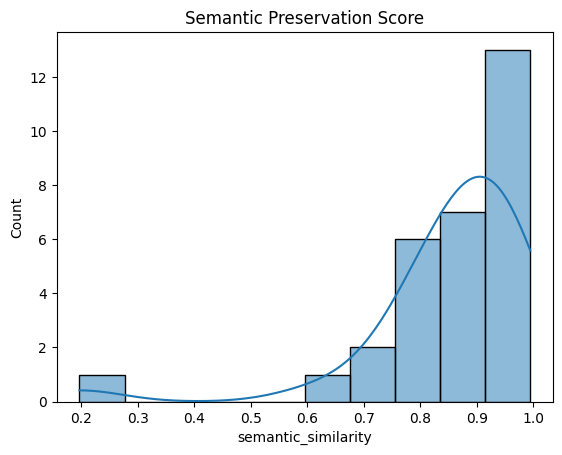

In [14]:
sns.histplot(df["semantic_similarity"], bins=10, kde=True)
plt.title("Semantic Preservation Score")
plt.show()

RESULT TABLE

In [15]:
df[[
    "source",
    "bias",
    "summary_bias",
    "rouge1",
    "compression_ratio",
    "semantic_similarity"
]].head(50)

,source,bias,summary_bias,rouge1,compression_ratio,semantic_similarity
0,The Verge,NEGATIVE,NEGATIVE,0.500000,0.364486,0.817159
1,Gizmodo.com,NEGATIVE,NEGATIVE,0.754098,0.579439,0.952818
2,The Verge,NEGATIVE,NEGATIVE,0.491228,0.462617,0.777486
3,The Verge,NEGATIVE,NEGATIVE,0.553191,0.397196,0.745674
4,Slashdot.org,NEGATIVE,NEGATIVE,0.923077,0.855140,0.969141
5,The Verge,NEGATIVE,NEGATIVE,0.549020,0.401869,0.723683
6,The Verge,NEGATIVE,NEGATIVE,0.857143,0.748837,0.914159
7,The Verge,NEGATIVE,NEGATIVE,0.861111,0.747664,0.849315
8,The Verge,POSITIVE,POSITIVE,0.588235,0.448598,0.890415
9,Gizmodo.com,NEGATIVE,NEGATIVE,0.967742,0.934579,0.972889


SUMMARY

In [16]:
final_text = " ".join(df["summary"].tolist())

final_summary = summarizer(
    final_text[:1024],
    max_length=150,
    min_length=60
)[0]["summary_text"]

print("\n🧾 FINAL NEUTRAL SUMMARY:\n")
print(final_summary)


🧾 FINAL NEUTRAL SUMMARY:

A Project 2025 splinter group declares war on AI and a16z. Robert F. Kennedy Jr. is launching a new podcast. The U7SG has improved reflection and blooming control, but it will be cheaper in a few months. The council will advise Trump on AI, the


Bias Reduction Metric


In [17]:
def bias_to_score(label):
    if label == "POSITIVE":
        return 1
    elif label == "NEGATIVE":
        return -1
    return 0

df["bias_score"] = df["bias"].apply(bias_to_score)
df["summary_bias_score"] = df["summary_bias"].apply(bias_to_score)

df["bias_reduction"] = df["bias_score"] - df["summary_bias_score"]

df[["bias_score", "summary_bias_score", "bias_reduction"]].head()

,bias_score,summary_bias_score,bias_reduction
0,-1,-1,0
1,-1,-1,0
2,-1,-1,0
3,-1,-1,0
4,-1,-1,0


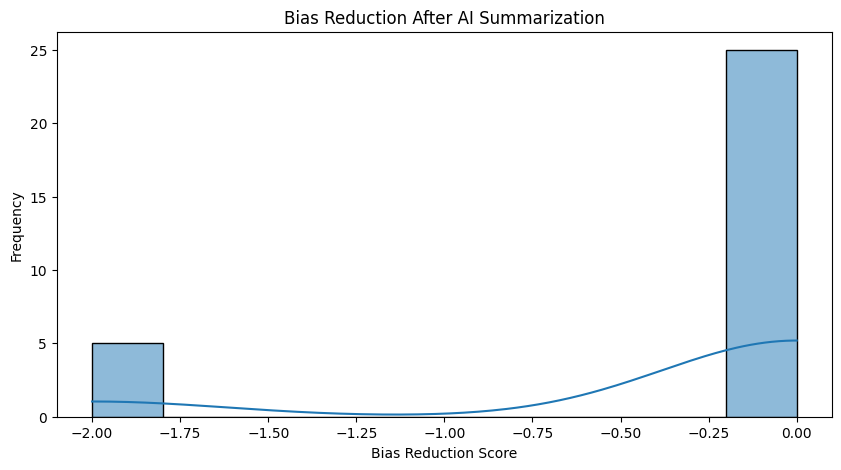

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(df["bias_reduction"], bins=10, kde=True)

plt.title("Bias Reduction After AI Summarization")
plt.xlabel("Bias Reduction Score")
plt.ylabel("Frequency")

plt.show()

DEMO


In [22]:
import time
from IPython.display import clear_output

for i in range(min(5, len(df))):
    clear_output(wait=True)

    print("📰 LIVE AI NEWS PROCESSING\n")
    print("="*60)

    print(f"ARTICLE {i+1}")

    print("\n📰 ORIGINAL NEWS:\n")
    print(df.iloc[i]["article"][:500])

    time.sleep(2)

    print("\n⚖️ DETECTED BIAS:", df.iloc[i]["bias"])

    time.sleep(1)

    print("\n🧠 AI SUMMARY:\n")
    print(df.iloc[i]["summary"])

    time.sleep(3)

    print("\n📊 BIAS REDUCTION SCORE:", df.iloc[i]["bias_reduction"])

    time.sleep(2)

📰 LIVE AI NEWS PROCESSING

ARTICLE 5

📰 ORIGINAL NEWS:

At Google, leaders are anxious about falling behind in the race to offer AI coding tools, especially as rivals like Anthropic PBC offer more effective and popular tools to businesses, according to pe… [+2569 chars]

⚖️ DETECTED BIAS: NEGATIVE

🧠 AI SUMMARY:

At Google, leaders are anxious about falling behind in the race to offer AI coding tools, especially as rivals like Anthropic PBC offer more effective and popular tools to businesses.

📊 BIAS REDUCTION SCORE: 0


METRICS

In [23]:
print("\n🧾 FINAL SYSTEM METRICS\n")

print("Total Articles:", len(df))
print("Avg Bias Reduction:", df["bias_reduction"].mean())
print("Avg Summary Length Ratio:",
      (df["summary"].str.len() / df["article"].str.len()).mean())


🧾 FINAL SYSTEM METRICS

Total Articles: 30
Avg Bias Reduction: -0.3333333333333333
Avg Summary Length Ratio: 0.6434043925296606


Comparison


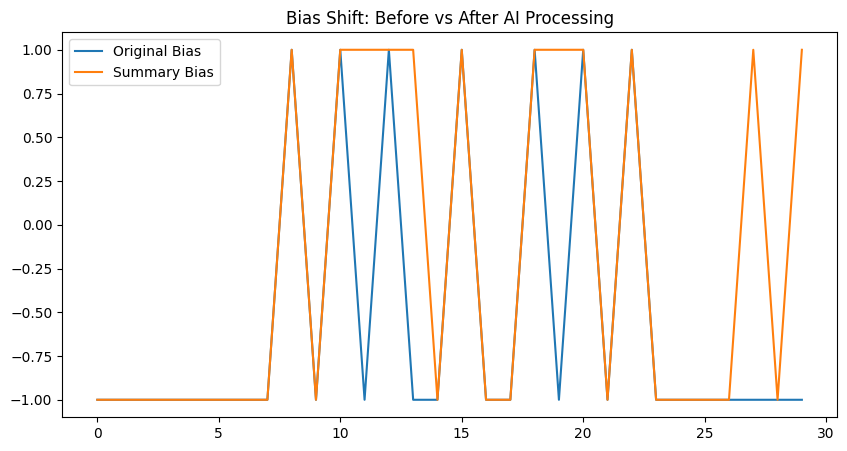

In [24]:
plt.figure(figsize=(10,5))

plt.plot(df["bias_score"].values, label="Original Bias")
plt.plot(df["summary_bias_score"].values, label="Summary Bias")

plt.title("Bias Shift: Before vs After AI Processing")
plt.legend()
plt.show()

Creating Pipeline

In [25]:
%%writefile pipeline.py
import spacy
from transformers import pipeline

nlp = spacy.load("en_core_web_sm")

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
sentiment = pipeline("sentiment-analysis")


def analyze(text):
    summary = summarizer(text[:1024], max_length=120, min_length=40, do_sample=False)[0]["summary_text"]
    bias = sentiment(text[:512])[0]

    return {
        "summary": summary,
        "bias_label": bias["label"],
        "bias_score": bias["score"]
    }


def bias_to_score(label):
    if label == "POSITIVE":
        return 1
    elif label == "NEGATIVE":
        return -1
    return 0

Writing pipeline.py


Creating App


In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
from newsapi import NewsApiClient
from pipeline import analyze, bias_to_score

st.set_page_config(page_title="AI News Bias Dashboard", layout="wide")

st.title("🧠 AI News Bias Detection & Summarization")

API_KEY = st.text_input("Enter NewsAPI Key", type="password")
query = st.text_input("Search Topic", "technology OR politics")
pages = st.slider("Pages", 1, 6, 3)


def fetch_news():
    newsapi = NewsApiClient(api_key=API_KEY)

    articles = []
    for page in range(1, pages + 1):
        res = newsapi.get_everything(
            q=query,
            language="en",
            page_size=20,
            page=page
        )
        articles.extend(res["articles"])

    return articles


if st.button("Run Analysis") and API_KEY:

    raw = fetch_news()

    data = []

    for a in raw:
        if a["content"]:
            result = analyze(a["content"])

            data.append({
                "source": a["source"]["name"],
                "article": a["content"][:800],
                "summary": result["summary"],
                "bias": result["bias_label"]
            })

    df = pd.DataFrame(data)

    df["bias_score"] = df["bias"].apply(bias_to_score)

    st.subheader("📰 Original vs AI Summary")

    for i, row in df.iterrows():
        col1, col2 = st.columns(2)

        with col1:
            st.markdown("### Original News")
            st.write(row["article"])
            st.write("⚖️ Bias:", row["bias"])

        with col2:
            st.markdown("### AI Summary")
            st.write(row["summary"])

        st.divider()

    st.subheader("📊 Bias Distribution")
    st.bar_chart(df["bias"].value_counts())

    st.metric("Avg Bias Score", df["bias_score"].mean())

Writing app.py


In [27]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://silly-pears-nail.loca.lt
^C
